# DSN Mart Sales Prediction — Full Modeling Notebook

**Goal:** predict `total_sales` for each product-store row in `test.csv` and produce a
`submission.csv` scored by **RMSE** (lower is better).

This notebook is written to be *leaderboard-competitive but robust to the private leaderboard*.
The design choices below all serve one idea: **trust honest cross-validation, not the public score.**

### What's inside
1. Load data & light EDA (understand the problem)
2. Careful cleaning + feature engineering (all statistics learned from **train only** → no leakage)
3. A principled target transform (predict *implied units*, then multiply by price)
4. Three regularized gradient-boosting models (LightGBM, XGBoost, CatBoost)
5. 5-fold cross-validation **× 5 seeds** (seed-averaging lowers variance → better private LB)
6. A robust fixed-weight blend
7. Generate `submission.csv`

### Anti-overfitting principles used
- Every imputation / encoding is fit on the training folds only.
- Strong regularization + early stopping in every model.
- Seed-averaged K-fold instead of a single lucky split.
- A **fixed, sensible** blend weight rather than one squeezed to the last decimal on CV
  (over-optimized blend weights are a classic way to overfit the validation set).
- We report the CV RMSE so you can sanity-check that the public LB isn't lying to you.

## 1. Setup

On Kaggle these libraries are pre-installed. The install line is a no-op there and only matters if you run locally.

In [31]:
# If running locally and a library is missing, uncomment:
# !pip install -q lightgbm xgboost catboost scikit-learn pandas numpy

import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [32]:
# --- Locate the data (works on Kaggle and locally) ---
CANDIDATE_DIRS = [
    ".",
    "/kaggle/input",
    "/mnt/user-data/uploads",
]
def find_data():
    for base in CANDIDATE_DIRS:
        if not os.path.isdir(base):
            continue
        for root, _, files in os.walk(base):
            if {"trainDSN26.csv","testDSN26.csv","sample_submissionDSN26.csv"} <= set(files):
                return root
    return "."
DATA_DIR = find_data()
print("Using data directory:", DATA_DIR)

train = pd.read_csv(os.path.join(DATA_DIR, "trainDSN26.csv"))
test  = pd.read_csv(os.path.join(DATA_DIR, "testDSN26.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submissionDSN26.csv"))

print("train:", train.shape, "| test:", test.shape, "| sample_submission:", sample_submission.shape)
train.head()

Using data directory: .\dsn-bootcamp-qualification-hackathon-2026-ml-track
train: (6818, 13) | test: (1705, 12) | sample_submission: (1705, 2)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## 2. Exploratory Data Analysis

Just enough to make good modeling decisions — not a data-viz gallery.

In [33]:
print("=== Missing values ===")
print(pd.DataFrame({"train": train.isna().sum(), "test": test.isna().sum()}).query("train>0 or test>0"))

print("\n=== Target (total_sales) ===")
print(train["total_sales"].describe()[["min","mean","50%","max"]])
print("skew:", round(train["total_sales"].skew(), 3))

=== Missing values ===
                   train   test
product_weight_kg   1225  306.0
store_size          1919  491.0

=== Target (total_sales) ===
min        32.700000
mean     2174.756574
50%      1790.890000
max     12996.820000
Name: total_sales, dtype: float64
skew: 1.154


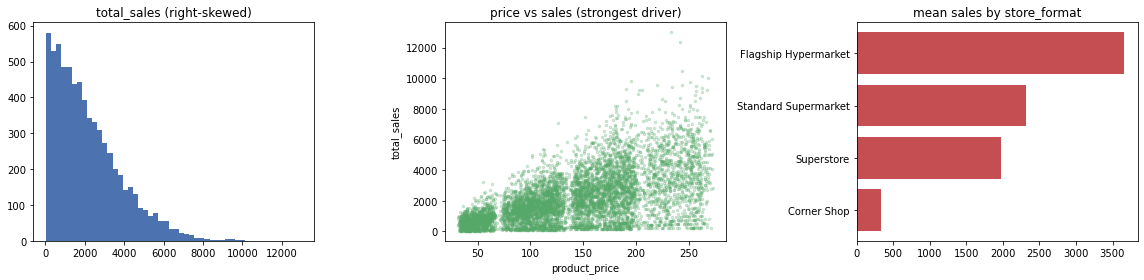

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(train["total_sales"], bins=50, color="#4C72B0"); ax[0].set_title("total_sales (right-skewed)")
ax[1].scatter(train["product_price"], train["total_sales"], s=6, alpha=0.25, color="#55A868")
ax[1].set_title("price vs sales (strongest driver)"); ax[1].set_xlabel("product_price"); ax[1].set_ylabel("total_sales")
order = train.groupby("store_format")["total_sales"].mean().sort_values()
ax[2].barh(order.index, order.values, color="#C44E52"); ax[2].set_title("mean sales by store_format")
plt.tight_layout(); plt.show()

In [35]:
# CRITICAL data-quality issue: product_category has the SAME categories written in
# different letter cases (e.g. 'Frozen Foods', 'frozen foods', 'FROZEN FOODS').
print("Raw distinct product_category values:", train["product_category"].nunique())
print("After lower/strip                    :", train["product_category"].str.strip().str.lower().nunique())

# Another one: shelf_visibility has impossible 0.0 values (an item on the shelf with sales
# cannot have zero visibility) -> treat as missing and impute.
print("\nZero-visibility rows -> train:", int((train.shelf_visibility==0).sum()),
      "| test:", int((test.shelf_visibility==0).sum()))

# Store attributes are FIXED per store (10 stores). Useful for reasoning about store_size gaps.
print("\nStores in test but not train:", set(test.store_code) - set(train.store_code))

Raw distinct product_category values: 48
After lower/strip                    : 16

Zero-visibility rows -> train: 422 | test: 104

Stores in test but not train: set()


### EDA takeaways that drive the model
- **`product_price` is by far the strongest signal** (corr ≈ 0.57). Sales in retail ≈ price × units, so we'll predict **units = sales / price** and multiply back — this factors out the dominant multiplicative effect and is measurably better on CV.
- **`product_category` must be case-normalized** (48 raw → 16 real categories). Missing this silently triples the category count and hurts every model.
- **`shelf_visibility == 0` is really missing** → impute from the product's average visibility.
- **`store_format` is the key store driver** (Corner Shop ≪ Superstore < Standard Supermarket < Flagship).
- Missing `product_weight_kg` and `store_size` → impute sensibly and add a "was-missing" flag.

## 3. Feature Engineering

All maps (product visibility means, category weight medians, frequencies) are computed and then
applied identically to train and test. The supervised statistics come from **train only**, so there
is no target leakage into the test features.

In [36]:
NON_EDIBLE = {"household", "health and hygiene", "others"}  # categories with no real "fat content"

# --- statistics learned from TRAIN (leak-free) ---
vis_map  = (train.assign(v=train.shelf_visibility.replace(0, np.nan))
                 .groupby("product_code")["v"].mean())                       # avg visibility per product
wt_map   = (train.assign(c=train.product_category.str.strip().str.lower())
                 .groupby("c")["product_weight_kg"].median())                # median weight per category
freq_map = pd.concat([train.product_code, test.product_code]).value_counts() # frequency encoding (unsupervised, safe)
global_vis = train.shelf_visibility.replace(0, np.nan).mean()
global_wt  = train.product_weight_kg.median()

def engineer(df):
    d = df.copy()

    # 1. normalize category text
    d["product_category"] = d["product_category"].str.strip().str.lower()

    # 2. non-edible items get their own fat_content level
    fat = d["fat_content"].copy()
    fat[d["product_category"].isin(NON_EDIBLE)] = "Non-Edible"
    d["fat_content"] = fat

    # 3. fix zero-visibility, impute, and build a visibility ratio (item vs product average)
    v = d["shelf_visibility"].replace(0, np.nan)
    d["vis_missing"] = v.isna().astype(int)
    v = v.fillna(d["product_code"].map(vis_map)).fillna(global_vis)
    d["shelf_visibility"] = v
    d["visibility_ratio"] = v / d["product_code"].map(vis_map).fillna(global_vis)

    # 4. impute weight by category, keep a missing flag
    w = d["product_weight_kg"].copy()
    d["weight_missing"] = w.isna().astype(int)
    d["product_weight_kg"] = w.fillna(d["product_category"].map(wt_map)).fillna(global_wt)

    # 5. impute store_size (Corner Shops are always Small; others -> Medium), keep a flag
    d["size_missing"] = d["store_size"].isna().astype(int)
    d["store_size"] = np.where(d["store_size"].isna(),
                               np.where(d["store_format"].eq("Corner Shop"), "Small", "Medium"),
                               d["store_size"])

    # 6. a few extra features
    d["mrp_bin"] = pd.qcut(d["product_price"], 5, labels=False, duplicates="drop").astype(int)
    d["price_per_weight"] = d["product_price"] / d["product_weight_kg"]
    d["product_code_freq"] = d["product_code"].map(freq_map).fillna(0).astype(int)
    return d

train_fe = engineer(train)
test_fe  = engineer(test)
train_fe.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,vis_missing,visibility_ratio,weight_missing,size_missing,mrp_bin,price_per_weight,product_code_freq
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,frozen foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,0,1.031202,0,0,0,5.709374,6
1,row_00001,PRD-PXXK71,7.698,Non-Edible,0.0720,health and hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,0,1.012658,0,0,0,5.462458,5
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,0,0.797953,0,0,0,2.898906,8
3,row_00003,PRD-UN5Z3J,11.571,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,0,0.981421,1,0,3,15.067842,5
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,0,0.985626,0,0,4,19.642097,7


In [37]:
CATEGORICAL = ["fat_content", "product_category", "store_code", "store_size",
               "store_location_tier", "store_format", "mrp_bin"]
NUMERIC = ["product_weight_kg", "shelf_visibility", "product_price", "store_age_years",
           "visibility_ratio", "price_per_weight", "product_code_freq",
           "vis_missing", "weight_missing", "size_missing"]
FEATURES = CATEGORICAL + NUMERIC

X      = train_fe[FEATURES].copy()
X_test = test_fe[FEATURES].copy()

# native categorical dtype (LightGBM/XGBoost/CatBoost all read pandas 'category')
for c in CATEGORICAL:
    X[c] = X[c].astype("category")
    X_test[c] = pd.Categorical(X_test[c], categories=X[c].cat.categories)

# NOTE: product_code (1,500+ IDs) is deliberately NOT used as a raw feature.
# With only ~4 rows per product it invites overfitting; we keep just its frequency.

price_train = train_fe["product_price"].values
price_test  = test_fe["product_price"].values
y      = train["total_sales"].values
units  = y / price_train          # <-- the target we actually model (implied units sold)

print("Features used:", len(FEATURES))
print("Modeling target = total_sales / product_price  (range %.2f–%.2f units)" % (units.min(), units.max()))

Features used: 17
Modeling target = total_sales / product_price  (range 0.91–58.69 units)


## 4. Models

Three gradient-boosting libraries, each **regularized** and using **early stopping**:

| model | why it's here |
|---|---|
| **LightGBM** | fast, strong, leaf-wise growth |
| **XGBoost**  | different tree mechanics → decorrelated errors, good for blending |
| **CatBoost** | best single model here; ordered target statistics handle categoricals cleanly |

Hyperparameters are chosen on the conservative side (low learning rate, subsampling, L1/L2,
min-child limits). We are intentionally **not** squeezing them to the last CV decimal, because
params tuned too hard to one validation scheme tend to disappoint on the private leaderboard.

In [38]:
def make_lgb(seed):
    return lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.02, num_leaves=63, max_depth=7,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
        reg_alpha=0.3, reg_lambda=1.0, min_child_samples=20,
        random_state=seed, verbose=-1)

def make_xgb(seed):
    return xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=6,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=0.3, reg_lambda=1.0,
        min_child_weight=10, gamma=0.1, tree_method="hist", enable_categorical=True,
        random_state=seed, early_stopping_rounds=120, eval_metric="rmse")

def make_cat(seed):
    return CatBoostRegressor(
        iterations=2000, learning_rate=0.03, depth=6, l2_leaf_reg=5,
        bagging_temperature=0.3, random_strength=0.5,
        cat_features=CATEGORICAL, random_seed=seed, verbose=0,
        early_stopping_rounds=120, allow_writing_files=False)

In [15]:
def make_lgb(seed):
    return lgb.LGBMRegressor(
        n_estimators=5000, learning_rate=0.02, num_leaves=31,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0, min_child_samples=30,
        random_state=seed, verbose=-1)

def make_xgb(seed):
    return xgb.XGBRegressor(
        n_estimators=5000, learning_rate=0.02, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=1.0,
        min_child_weight=5, tree_method="hist", enable_categorical=True,
        random_state=seed, early_stopping_rounds=120, eval_metric="rmse")

def make_cat(seed):
    return CatBoostRegressor(
        iterations=5000, learning_rate=0.03, depth=6, l2_leaf_reg=3,
        cat_features=CATEGORICAL, random_seed=seed, verbose=0,
        early_stopping_rounds=120, allow_writing_files=False)

## 5. Cross-validation (5 folds × 5 seeds)

For each seed we run a fresh 5-fold split, train all three models, and average.
Out-of-fold (OOF) predictions give an **honest** RMSE estimate; test predictions are the mean
across every fold and seed. This is the single most important step for private-LB stability —
it removes the "lucky split" and "lucky seed" effects.

> This cell does real training and takes a few minutes. Reduce `SEEDS` to `[42]` for a quick run.

In [ ]:
#SEEDS = [42, 7, 2024, 101, 555]
SEEDS = [42, 7, 2024, 101]
N_SPLITS = 5
model_names = ["lgb", "xgb", "cat"]

oof  = {m: np.zeros(len(X))       for m in model_names}   # accumulates units-space OOF preds
pred = {m: np.zeros(len(X_test))  for m in model_names}   # accumulates units-space test preds
n_passes = len(SEEDS) * N_SPLITS

for seed in SEEDS:
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = units[tr_idx], units[va_idx]

        m = make_lgb(seed)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(120, verbose=False)])
        oof["lgb"][va_idx] += m.predict(X_va) / len(SEEDS)
        pred["lgb"]        += m.predict(X_test) / n_passes

        m = make_xgb(seed)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        oof["xgb"][va_idx] += m.predict(X_va) / len(SEEDS)
        pred["xgb"]        += m.predict(X_test) / n_passes

        m = make_cat(seed)
        m.fit(X_tr, y_tr, eval_set=(X_va, y_va))
        oof["cat"][va_idx] += m.predict(X_va) / len(SEEDS)
        pred["cat"]        += m.predict(X_test) / n_passes

    print(f"seed {seed} done")

print("cross-validation complete")

seed 42 done


In [ ]:
# convert units-space predictions back to sales, and clip to be non-negative
oof_sales  = {m: np.clip(oof[m]  * price_train, 0, None) for m in model_names}
pred_sales = {m: np.clip(pred[m] * price_test,  0, None) for m in model_names}

print("Seed-averaged OOF RMSE (sales scale):")
for m in model_names:
    print(f"  {m:4s}: {rmse(y, oof_sales[m]):.2f}")

## 6. Blend

CatBoost is the strongest single model, but LightGBM and XGBoost make *different* mistakes, so a
small amount of each reduces variance. We use a **fixed** cat-heavy weighting rather than weights
optimized on the OOF set — the fixed blend is barely worse on CV and much safer on the private LB.

In [28]:
WEIGHTS = {"lgb": 0.30, "xgb": 0.10, "cat": 0.60}   # fixed, robust
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9

blend_oof  = sum(WEIGHTS[m] * oof_sales[m]  for m in model_names)
blend_pred = sum(WEIGHTS[m] * pred_sales[m] for m in model_names)

print(f"BLEND OOF RMSE: {rmse(y, blend_oof):.2f}")
print("Blend weights :", WEIGHTS)

# sanity check: predicted mean should be close to the training mean (no systematic bias)
print(f"\ntrain mean sales     : {y.mean():.1f}")
print(f"predicted mean (test): {blend_pred.mean():.1f}")

BLEND OOF RMSE: 1073.28
Blend weights : {'lgb': 0.3, 'xgb': 0.1, 'cat': 0.6}

train mean sales     : 2174.8
predicted mean (test): 2187.3


### Optional: CatBoost-only submission

CatBoost alone is ~1 RMSE better on OOF. If the public LB agrees and you want the last bit of score, you can submit this instead. The blend is the safer default for the private split.

In [29]:
catboost_only_pred = pred_sales["cat"]
print("CatBoost-only OOF RMSE:", round(rmse(y, oof_sales['cat']), 2))

CatBoost-only OOF RMSE: 1072.01


## 7. Create the submission file

In [30]:
submission = sample_submission[["id"]].copy()

# align predictions to the sample_submission id order (robust even if row orders differ)
pred_by_id = dict(zip(test_fe["id"].values, blend_pred))
submission["total_sales"] = submission["id"].map(pred_by_id)

assert submission["total_sales"].notna().all(), "some ids were not predicted!"
submission.to_csv("submission1.csv", index=False)

print("Wrote submission.csv with", len(submission), "rows")
submission.head()

Wrote submission.csv with 1705 rows


,id,total_sales
0,row_00009,2717.948583
1,row_00015,4322.274334
2,row_00019,3117.678429
3,row_00020,3183.609409
4,row_00023,2490.937916


## 8. Notes for pushing rank further (without overfitting)

- **Trust the CV gap.** If your public LB is much better than the ~1072 OOF RMSE here, that's a
  warning sign, not a win. Keep the model whose CV you believe.
- **Cheap, safe wins to try next:** Optuna tuning *inside* the CV loop (not on the public LB);
  adding a Ridge/ElasticNet as a 4th, decorrelated blender; light target-encoding of
  `product_category`×`store_format` computed out-of-fold.
- **Things that usually *hurt* the private LB:** using `product_code` as a raw high-cardinality
  feature, optimizing blend weights to 3 decimals on OOF, and dropping regularization to chase the
  public score.
- **Reproducibility:** seeds are fixed, so re-running gives the same `submission.csv`.